# Introdução

---



A evasão de clientes, conhecida como Churn, ocorre quando um cliente decide cancelar ou interromper o uso de um serviço. Em empresas que trabalham com modelos de assinatura ou serviços recorrentes, compreender os fatores que levam ao churn é essencial para melhorar a retenção de clientes e aumentar a receita.

O objetivo deste estudo é analisar um conjunto de dados contendo informações sobre clientes de uma empresa de telecomunicações, identificando padrões e fatores que influenciam o cancelamento de serviços.

A análise utiliza técnicas de análise exploratória de dados (EDA) para compreender o comportamento dos clientes e gerar insights estratégicos que possam ajudar a reduzir a evasão.

O dataset contém 7032 registros de clientes, incluindo características demográficas, serviços contratados, tempo de relacionamento com a empresa e valores de cobrança.

# Limpeza e Tratamento de Dados

---



Antes de iniciar as análises, foi necessário realizar algumas etapas de preparação dos dados para garantir a qualidade das informações.

Inicialmente, os dados foram importados utilizando a biblioteca Pandas. Em seguida, foram realizadas verificações para compreender a estrutura do dataset, identificar possíveis valores ausentes e verificar o tipo de cada variável.

As principais etapas realizadas foram:

Importação do dataset utilizando Pandas

Verificação da estrutura dos dados com info() e describe()

Padronização dos nomes das colunas

Conversão de variáveis categóricas em valores numéricos

Verificação de valores nulos ou inconsistentes

Ajustes em variáveis que representavam serviços contratados

Após essas etapas, os dados ficaram organizados e preparados para a etapa de análise exploratória.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_json('/content/TelecomX_Data.json')
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
# Expandindo colunas

# expandir customer
customer_df = pd.json_normalize(df['customer'])

# expandir phone
phone_df = pd.json_normalize(df['phone'])

# expandir internet
internet_df = pd.json_normalize(df['internet'])

# expandir account
account_df = pd.json_normalize(df['account'])

In [3]:
# Construindo DataSet

df = pd.concat(
    [
        df.drop(['customer','phone','internet','account'], axis=1),
        customer_df,
        phone_df,
        internet_df,
        account_df
    ],
    axis=1
)

In [4]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# Transformação

---



In [5]:
# Verificando valores Duplicados

df.duplicated().sum()

np.int64(0)

In [6]:
# Verificando valores Nulos

df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [7]:
# Verificando valores Vazios ou em Branco

df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [8]:
# Limpando valores Vazios ou em Branco

df = df[df['Churn'].astype(str).str.strip() != '']
df = df[df['Charges.Total'].astype(str).str.strip() != '']

In [9]:
# Confirmando existencias de valores Vazios ou em Branco

df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [10]:
# Incluindo coluna contas_diarias

df['contas_diarias'] = df['Charges.Monthly'] / 30

In [11]:
# Padronizando nome das colunas

df = df.rename (columns = {
    'customerID': 'id_cliente',
    'cancelamento': 'Churn',
    'gender': 'genero',
    'SeniorCitizen': 'tem +65',
    'Partner': 'possui_parceiro',
    'Dependents': 'possui_dependentes',
    'tenure': 'tempo_cliente_meses',
    'PhoneService': 'servico_telefone',
    'MultipleLines': 'multiplas_linhas',
    'InternetService': 'servico_internet',
    'OnlineSecurity': 'seguranca_online',
    'OnlineBackup': 'backup_online',
    'DeviceProtection': 'protecao_dispositivo',
    'TechSupport': 'suporte_tecnico',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_filmes',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'fatura_digital',
    'PaymentMethod': 'metodo_pagamento',
    'Charges.Monthly': 'gasto_mensal',
    'Charges.Total': 'gasto_total'
})

In [12]:
df.head()

,id_cliente,Churn,genero,tem +65,possui_parceiro,possui_dependentes,tempo_cliente_meses,servico_telefone,multiplas_linhas,servico_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,gasto_mensal,gasto_total,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


In [13]:
# Tradução colunas apenas com valores Sim e Não
colunas_sim_nao = [
    'Churn', 'possui_parceiro', 'possui_dependentes',
    'servico_telefone', 'fatura_digital'
]

df[colunas_sim_nao] = (
    df[colunas_sim_nao]
    .replace({'Yes': 'Sim', 'No': 'Não'})
)



In [14]:
df_traduzido = df

In [15]:
# Tradução colunas Sim, Não, Sem serviço Internet
colunas_sem_internet = [
    'seguranca_online', 'backup_online',
    'protecao_dispositivo', 'suporte_tecnico',
    'streaming_tv', 'streaming_filmes'
]

df_traduzido[colunas_sem_internet] = (
    df_traduzido[colunas_sem_internet]
    .replace({'Yes': 'Sim', 'No': 'Não', 'No internet service': 'Sem serviço de internet'})
)

# Traduções Diversas
df_traduzido['multiplas_linhas'] = df_traduzido['multiplas_linhas'].replace({'Yes': 'Sim', 'No': 'Não', 'No phone service': 'Sem serviço de telefone'})
df_traduzido['genero'] = df_traduzido['genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df_traduzido['servico_internet'] = df_traduzido['servico_internet'].replace({'Fiber optic': 'Fibra Opica', 'No': 'Sem servico de internet'})
df_traduzido['tipo_contrato'] = df_traduzido['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensal', 'Two year': 'Bienal'})
df_traduzido['metodo_pagamento'] = df_traduzido['metodo_pagamento'].replace({'Mailed check':'Cheque fisico',
                                                                             'Electronic check':'Cheque eletrônico',
                                                                             'Credit card (automatic)':	'Cartão de crédito',
                                                                             'Bank transfer (automatic)':	'Transferência bancária'})

In [16]:
df_traduzido['gasto_mensal'] = df['gasto_mensal'].round(2)
df_traduzido['gasto_total'] = df['gasto_total'].round(2)
df_traduzido['contas_diarias'] = df['contas_diarias'].round(2)

In [17]:
df_traduzido

,id_cliente,Churn,genero,tem +65,possui_parceiro,possui_dependentes,tempo_cliente_meses,servico_telefone,multiplas_linhas,servico_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,gasto_mensal,gasto_total,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque fisico,65.60,593.3,2.19
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque fisico,59.90,542.4,2.00
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fibra Opica,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.46
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fibra Opica,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.27
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fibra Opica,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque fisico,83.90,267.4,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Não,Feminino,0,Não,Não,13,Sim,Não,DSL,...,Não,Sim,Não,Não,Anual,Não,Cheque fisico,55.15,742.9,1.84
7263,9992-RRAMN,Sim,Masculino,0,Sim,Não,22,Sim,Sim,Fibra Opica,...,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.7,2.84
7264,9992-UJOEL,Não,Masculino,0,Não,Não,2,Sim,Não,DSL,...,Não,Não,Não,Não,Mensal,Sim,Cheque fisico,50.30,92.75,1.68
7265,9993-LHIEB,Não,Masculino,0,Sim,Sim,67,Sim,Não,DSL,...,Sim,Sim,Não,Sim,Bienal,Não,Cheque fisico,67.85,4627.65,2.26


In [19]:
df_bin = df_traduzido.copy()

In [20]:
# binarização

# cópia
mapa_binario = {'Sim': 1, 'Não': 0, 'Sem serviço de internet': 0, 'Sem serviço de telefone': 0}

colunas_binarias = [
    'Churn', 'possui_parceiro', 'possui_dependentes',
    'servico_telefone', 'fatura_digital',
    'seguranca_online', 'backup_online',
    'protecao_dispositivo', 'suporte_tecnico',
    'streaming_tv', 'streaming_filmes', 'multiplas_linhas'
]

df_bin[colunas_binarias] = df_bin[colunas_binarias].replace(mapa_binario)

# verifica
df_bin[colunas_binarias].head()

/tmp/ipykernel_7956/1256565462.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bin[colunas_binarias] = df_bin[colunas_binarias].replace(mapa_binario)


,Churn,possui_parceiro,possui_dependentes,servico_telefone,fatura_digital,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,multiplas_linhas
0,0,1,1,1,1,0,1,0,1,1,0,0
1,0,0,0,1,0,0,0,0,0,0,1,1
2,1,0,0,1,1,0,0,1,0,0,0,0
3,1,1,0,1,1,0,1,1,0,1,1,0
4,1,1,0,1,1,0,0,0,1,1,0,0


In [21]:
df_bin

,id_cliente,Churn,genero,tem +65,possui_parceiro,possui_dependentes,tempo_cliente_meses,servico_telefone,multiplas_linhas,servico_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,gasto_mensal,gasto_total,contas_diarias
0,0002-ORFBO,0,Feminino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Cheque fisico,65.60,593.3,2.19
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensal,0,Cheque fisico,59.90,542.4,2.00
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fibra Opica,...,1,0,0,0,Mensal,1,Cheque eletrônico,73.90,280.85,2.46
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fibra Opica,...,1,0,1,1,Mensal,1,Cheque eletrônico,98.00,1237.85,3.27
4,0013-EXCHZ,1,Feminino,1,1,0,3,1,0,Fibra Opica,...,0,1,1,0,Mensal,1,Cheque fisico,83.90,267.4,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Feminino,0,0,0,13,1,0,DSL,...,0,1,0,0,Anual,0,Cheque fisico,55.15,742.9,1.84
7263,9992-RRAMN,1,Masculino,0,1,0,22,1,1,Fibra Opica,...,0,0,0,1,Mensal,1,Cheque eletrônico,85.10,1873.7,2.84
7264,9992-UJOEL,0,Masculino,0,0,0,2,1,0,DSL,...,0,0,0,0,Mensal,1,Cheque fisico,50.30,92.75,1.68
7265,9993-LHIEB,0,Masculino,0,1,1,67,1,0,DSL,...,1,1,0,1,Bienal,0,Cheque fisico,67.85,4627.65,2.26


In [22]:
df_final = df_bin.drop(columns = ['id_cliente'])

In [23]:
df_final

,Churn,genero,tem +65,possui_parceiro,possui_dependentes,tempo_cliente_meses,servico_telefone,multiplas_linhas,servico_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,gasto_mensal,gasto_total,contas_diarias
0,0,Feminino,0,1,1,9,1,0,DSL,0,...,0,1,1,0,Anual,1,Cheque fisico,65.60,593.3,2.19
1,0,Masculino,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Mensal,0,Cheque fisico,59.90,542.4,2.00
2,1,Masculino,0,0,0,4,1,0,Fibra Opica,0,...,1,0,0,0,Mensal,1,Cheque eletrônico,73.90,280.85,2.46
3,1,Masculino,1,1,0,13,1,0,Fibra Opica,0,...,1,0,1,1,Mensal,1,Cheque eletrônico,98.00,1237.85,3.27
4,1,Feminino,1,1,0,3,1,0,Fibra Opica,0,...,0,1,1,0,Mensal,1,Cheque fisico,83.90,267.4,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,Feminino,0,0,0,13,1,0,DSL,1,...,0,1,0,0,Anual,0,Cheque fisico,55.15,742.9,1.84
7263,1,Masculino,0,1,0,22,1,1,Fibra Opica,0,...,0,0,0,1,Mensal,1,Cheque eletrônico,85.10,1873.7,2.84
7264,0,Masculino,0,0,0,2,1,0,DSL,0,...,0,0,0,0,Mensal,1,Cheque fisico,50.30,92.75,1.68
7265,0,Masculino,0,1,1,67,1,0,DSL,1,...,1,1,0,1,Bienal,0,Cheque fisico,67.85,4627.65,2.26


# Análise Exploratória de Dados

---



A análise exploratória foi realizada para identificar padrões e possíveis fatores associados ao churn.

In [26]:
df_final.describe()

,Churn,tem +65,possui_parceiro,possui_dependentes,tempo_cliente_meses,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,fatura_digital,gasto_mensal,contas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,64.798208,2.159891
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,30.085974,1.002955
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,1.187500
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,2.992500
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,3.960000


## Distribuição de Cancelamento de Clientes

O primeiro passo foi analisar a distribuição da variável Churn, que indica se o cliente cancelou ou permaneceu com o serviço.

Observa-se que a maior parte dos clientes permanece na empresa, enquanto aproximadamente 36% cancelaram o serviço. Apesar de a maioria continuar ativa, a taxa de cancelamento é significativa e pode impactar diretamente a receita da empresa.

/tmp/ipykernel_7956/4002843860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df_final, palette=['#42a5f5', '#8B0000'])


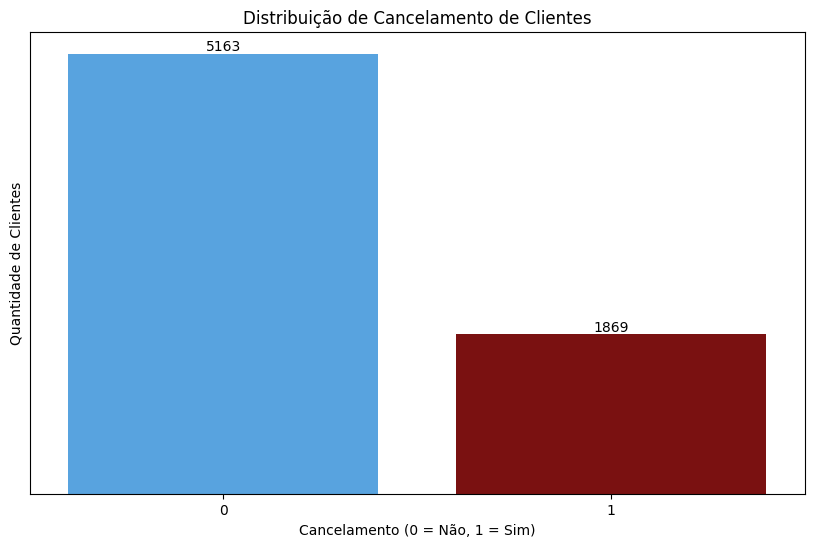

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ax = sns.countplot(x='Churn', data=df_final, palette=['#42a5f5', '#8B0000'])

# título e rótulos
plt.title('Distribuição de Cancelamento de Clientes')
plt.xlabel('Cancelamento (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Clientes')

# remover apenas as graduações do eixo Y
ax.set_yticks([])

# adicionar valores em cima das barras
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

## Churn vs Suporte Técnico

Clientes que não possuem suporte técnico geralmente apresentam taxas de cancelamento muito maiores do que aqueles que possuem esse serviço.

Ao analisarmos o gráfico, percebemos que:

- clientes sem suporte técnico apresentam maior taxa de churn

- clientes com suporte técnico tendem a permanecer mais tempo na empresa

Isso sugere que o acesso ao suporte pode melhorar a experiência do cliente e reduzir cancelamentos.

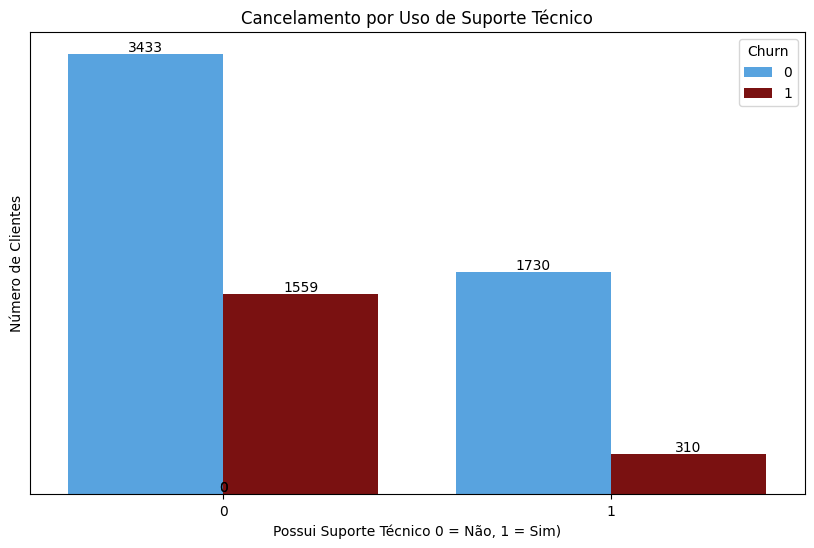

In [95]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x="suporte_tecnico", hue="Churn", data=df_final, palette=['#42a5f5', '#8B0000'])

plt.title("Cancelamento por Uso de Suporte Técnico")
plt.xlabel("Possui Suporte Técnico 0 = Não, 1 = Sim)")
plt.ylabel("Número de Clientes")

ax.set_yticks([])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )


plt.show()

## Cancelamento por Gênero

Em seguida, foi analisada a relação entre gênero e cancelamento.

Os resultados mostram que não há diferença significativa entre os gêneros em relação ao cancelamento, indicando que o churn parece não estar fortemente relacionado a essa característica demográfica.

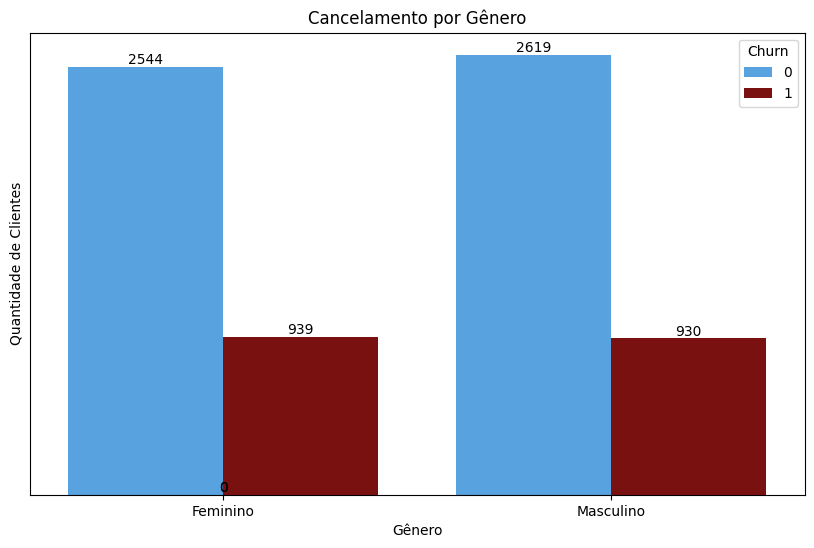

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ax = sns.countplot(x='genero', hue='Churn', data=df_final, palette=['#42a5f5', '#8B0000'])

plt.title('Cancelamento por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Clientes')


ax.set_yticks([])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

## Cancelamento por Tipo de Contrato

O tipo de contrato é um fator importante na retenção de clientes.

Observa-se que clientes com contratos mensais (month-to-month) apresentam uma taxa de cancelamento significativamente maior em comparação com clientes que possuem contratos anuais ou bienais.

Isso sugere que contratos mais longos ajudam a reduzir a probabilidade de churn.

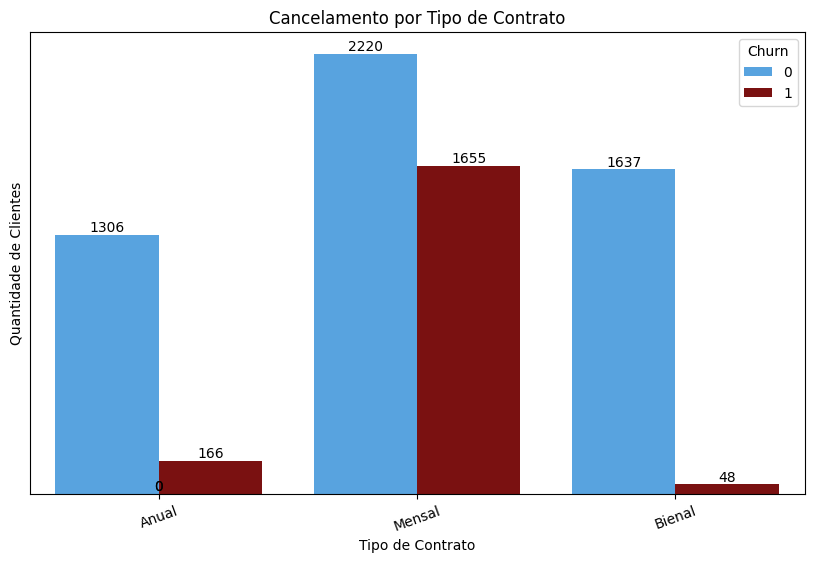

In [78]:
plt.figure(figsize=(10,6))

ax = sns.countplot(x='tipo_contrato', hue='Churn', data=df_final, palette=['#42a5f5', '#8B0000'])

plt.title('Cancelamento por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')

ax.set_yticks([])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )


plt.xticks(rotation=20)

plt.show()

## Cancelamento por Método de Pagamento

Também foi analisado o método de pagamento utilizado pelos clientes.

A análise mostra que clientes que utilizam Electronic Check apresentam maior taxa de cancelamento quando comparados a outros métodos de pagamento.

Isso pode indicar maior instabilidade nesse perfil de cliente.

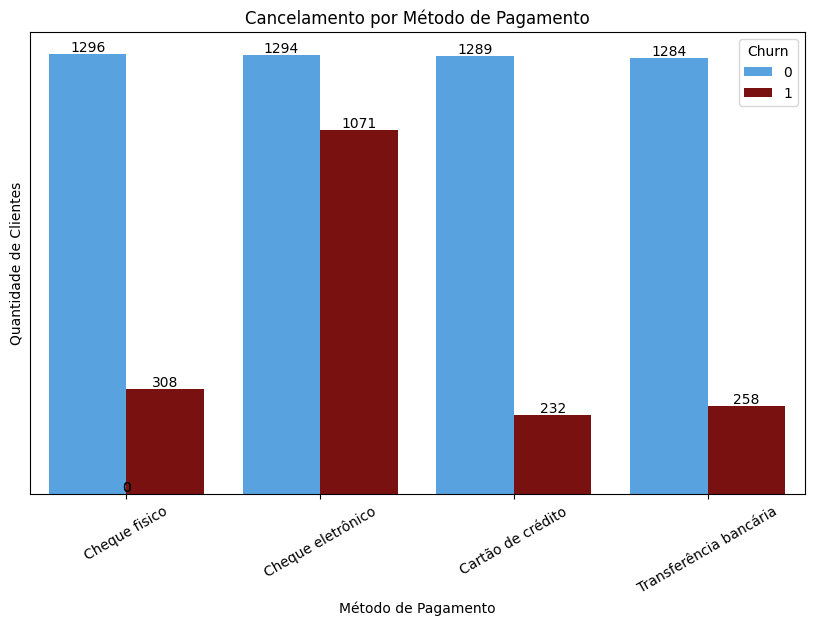

In [85]:
plt.figure(figsize=(10,6))

ax = sns.countplot(x='metodo_pagamento', hue='Churn', data=df_final, palette=['#42a5f5', '#8B0000'])

plt.title('Cancelamento por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade de Clientes')

ax.set_yticks([])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=30)

plt.show()

## Cancelamento por Tipo de Internet

Outra variável relevante é o tipo de serviço de internet contratado.

Clientes que utilizam fibra óptica apresentam uma taxa de churn mais elevada do que aqueles que utilizam DSL ou não possuem serviço de internet.

Esse resultado pode indicar questões relacionadas a preço ou expectativa de qualidade do serviço.

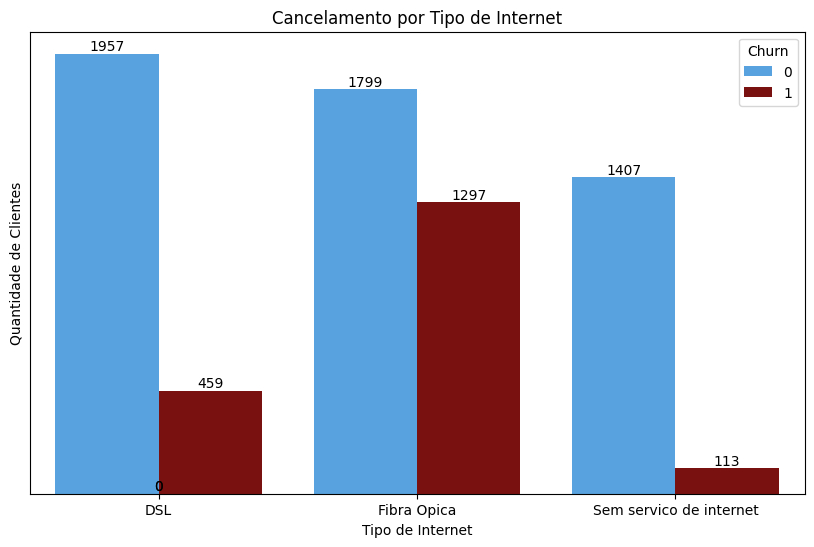

In [74]:
plt.figure(figsize=(10,6))

ax = sns.countplot(x='servico_internet', hue='Churn', data=df_final, palette=['#42a5f5', '#8B0000'])


plt.title('Cancelamento por Tipo de Internet')
plt.xlabel('Tipo de Internet')
plt.ylabel('Quantidade de Clientes')

ax.set_yticks([])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

## Tempo de Cliente vs Cancelamento

A relação entre o tempo de relacionamento com a empresa e o cancelamento também foi analisada.

Observa-se que clientes com menor tempo de relacionamento apresentam maior probabilidade de cancelar o serviço.

Isso indica que os primeiros meses de relacionamento são críticos para a retenção de clientes.

/tmp/ipykernel_7956/3790924986.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tempo_cliente_meses', data=df_final, palette=['#42a5f5', '#8B0000'])


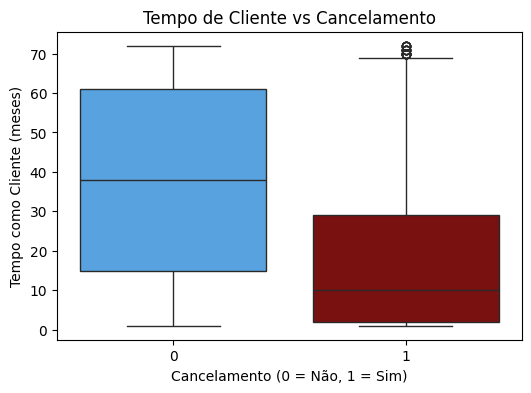

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(x='Churn', y='tempo_cliente_meses', data=df_final, palette=['#42a5f5', '#8B0000'])

plt.title('Tempo de Cliente vs Cancelamento')
plt.xlabel('Cancelamento (0 = Não, 1 = Sim)')
plt.ylabel('Tempo como Cliente (meses)')

plt.show()

## Gasto Mensal vs Cancelamento

Ao observar o gráfico, nota-se que clientes que cancelaram o serviço tendem a apresentar gastos mensais mais elevados quando comparados aos clientes que permaneceram.

Isso pode indicar que:

clientes com planos mais caros podem estar mais sensíveis ao custo do serviço

a percepção de custo-benefício pode influenciar a decisão de cancelar

clientes que pagam mais podem ter maiores expectativas sobre a qualidade do serviço

Esse padrão sugere que o preço ou a estrutura dos planos pode impactar diretamente a taxa de churn.

/tmp/ipykernel_7956/162169170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='gasto_mensal', data=df_final, palette=['#42a5f5', '#8B0000'])


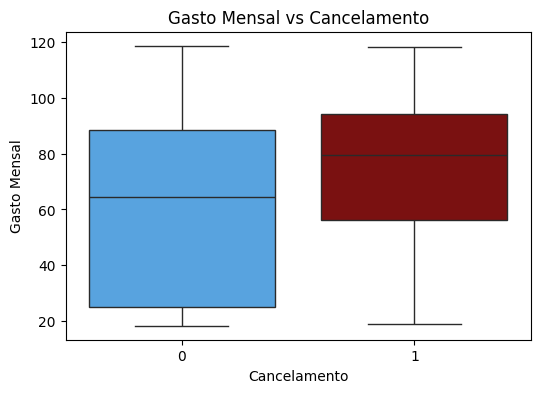

In [80]:
plt.figure(figsize=(6,4))

sns.boxplot(x='Churn', y='gasto_mensal', data=df_final, palette=['#42a5f5', '#8B0000'])

plt.title('Gasto Mensal vs Cancelamento')
plt.xlabel('Cancelamento')
plt.ylabel('Gasto Mensal')

plt.show()

# Conclusões e Insights

A análise exploratória permitiu identificar alguns fatores importantes associados ao churn.

Principais insights:

- A taxa de churn no dataset é de aproximadamente 36%.

- Clientes com contratos mensais apresentam maior probabilidade de cancelamento.

- O método de pagamento Electronic Check está associado a taxas mais altas de churn.

- Clientes com menor tempo de relacionamento são mais propensos a cancelar.

- Clientes com gastos mensais elevados também apresentam maior risco de churn.

Esses padrões ajudam a identificar perfis de clientes com maior risco de evasão.

# Recomendações

Com base nos resultados encontrados, algumas estratégias podem ser sugeridas para reduzir o churn.

**Melhorar retenção de novos clientes**

Criar estratégias focadas nos primeiros meses do cliente, como:

- onboarding estruturado

- suporte prioritário

- benefícios iniciais


**Incentivar contratos mais longos**


Clientes com contratos anuais apresentam menor churn. A empresa pode incentivar isso através de:

- descontos em planos anuais

- benefícios exclusivos para contratos longos


**Revisar estratégias de preço**

Clientes com maior gasto mensal apresentam maior risco de cancelamento. Possíveis ações:

- revisão de planos

- criação de pacotes mais competitivos

- descontos por fidelidade

**Investir em modelos preditivos de churn**

Utilizando técnicas de Machine Learning, a empresa pode prever quais clientes possuem maior probabilidade de cancelar e agir preventivamente.